In [20]:
import tensorflow as tf
import tensorflow_decision_forests as tfdf
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
import shap
from collections import defaultdict
import re

In [21]:
cali_housing_path = '../data/California_Houses.csv'
RANDOM_SEED = 492
cali_df = pd.read_csv(cali_housing_path)
y_series = cali_df['Median_House_Value']
y = pd.DataFrame(y_series, columns=['Median_House_Value'])
features = [col for col in cali_df.columns if col != 'Median_House_Value']
X = cali_df[features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [22]:
def generate_random_column(column):
    min_val = column.min()
    max_val = column.max()
    n_samples = len(column)
    
    if pd.api.types.is_integer_dtype(column):
        return np.random.randint(min_val, max_val + 1, size=n_samples)
    elif pd.api.types.is_float_dtype(column):
        return np.random.uniform(min_val, max_val, size=n_samples)
    else:
        # For categorical or object types, randomly sample from unique values
        return np.random.choice(column.unique(), size=n_samples)

# Generate random y_train
random_y_train = pd.DataFrame()

for column in y_train.columns:
    random_y_train[column] = generate_random_column(y_train[column])

# Reset index
random_y_train = random_y_train.reset_index(drop=True)

In [23]:
class GradientBoostedTreesEnsembleRegressor(tf.keras.Model):
    def __init__(self, n_trees=100, max_depth=3, n_estimators=100, subportion = 0.8, sample_method = "RANDOM",verbose = 1): 
        super(GradientBoostedTreesEnsembleRegressor, self).__init__()
        self.n_trees = n_trees
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.subportion = subportion
        self.sample_method = sample_method
        self.verbose = verbose
        self.estimators = []
        self.lime_explainers = []
        self.shap_explainers = []

    def build_estimator(self):
        model = tfdf.keras.GradientBoostedTreesModel(
            task=tfdf.keras.Task.REGRESSION,
            num_trees=np.random.randint(self.n_trees//5, self.n_trees+1), # self.n_trees, #
            max_depth=self.max_depth, #np.random.randint(self.max_depth/2, self.max_depth+1), # self.max_depth, # 
            validation_ratio=0.1,
            subsample=self.subportion,
            sampling_method=self.sample_method,
            random_seed=self.seed, # try to set this first. Maybe this is enough
            verbose=1
        )
        return model
    
    # if not, the number of trees/depth different for each estimator

    def fit(self, X, y):
        
        X_tensor = tf.constant(X.values, dtype=tf.float32)
        y_tensor = tf.constant(y.values, dtype=tf.float32)
        tot_dataset_size = len(X)
        
        for seed in np.random.randint(0, 1000000, size=self.n_estimators):
            self.seed = int(seed)
            subset_size = int(self.subportion * tot_dataset_size)
            
            # Create a subset of the dataset using sampled indices
            subset_indices = np.random.choice(tot_dataset_size, size=subset_size, replace=False)
            X_subset = tf.gather(X_tensor, subset_indices)
            y_subset = tf.gather(y_tensor, subset_indices)
            
            # subset_dataset = (X_tensor, y_tensor)
            
            # building each estimator
            estimator = self.build_estimator()
            estimator.fit(X_subset,y_subset,verbose=0)
            self.estimators.append(estimator)
            
        # initiate explainers
        for model in self.estimators:
            lime_explainer = LimeTabularExplainer(X.values, feature_names=X.columns.tolist(), mode='regression')
            self.lime_explainers.append(lime_explainer)
            masker = shap.maskers.Independent(data = X_train.values)
            shap_explainer = shap.Explainer(model, masker=masker, feature_names=X.columns.tolist())
            self.shap_explainers.append(shap_explainer)
    
    #something's not right here
    def predict_mean(self, X):
        predictions = []
        
        for estimator in self.estimators:
            estimator_predictions = estimator.predict(X,verbose=0)  # Get predictions from the current estimator
            predictions.append(estimator_predictions)
        
        # Stack all predictions along the last axis (-1)
        predictions_stacked = tf.stack(predictions, axis=-1)
        
        # Compute mean and variance across the stacked predictions
        mean_prediction = tf.reduce_mean(predictions_stacked, axis=-1)
        sd_prediction = tf.math.reduce_std(predictions_stacked, axis=-1)
        
        return mean_prediction, sd_prediction
    
    def explain_lime(self, X):
        lime_explanations = []
        
        for estimator, explainer in zip(self.estimators, self.lime_explainers):
            for i in range(len(X)): 
                instance_explanation = explainer.explain_instance(X.iloc[i], estimator.predict, num_features=X.shape[1])
                lime_explanations.append(instance_explanation)
        return lime_explanations
    
    def explain_shap(self, X):
        shap_values = []
        
        for estimator, explainer in zip(self.estimators, self.shap_explainers):
            shap_value = explainer(X)
            shap_values.append(shap_value)
        
        return shap_values
    

In [24]:
gbt_insane_model = GradientBoostedTreesEnsembleRegressor(
    n_trees=50, 
    max_depth=5, 
    n_estimators=80, 
    subportion=0.8, 
    sample_method='RANDOM',
    verbose=1
)
gbt_insane_model.compile(metrics=["mse"])
gbt_insane_model.fit(X_train_scaled, random_y_train)

Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmp1nd_fmgk as temporary training directory


[WARNING 24-07-31 15:39:54.5618 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:39:54.5620 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:39:54.5621 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpp29re8ry as temporary training directory


[INFO 24-07-31 15:39:54.9505 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmp1nd_fmgk/model/ with prefix f19410d7ad0c4a06
[INFO 24-07-31 15:39:54.9513 CEST abstract_model.cc:1344] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 24-07-31 15:39:54.9513 CEST kernel.cc:1061] Use fast generic engine
[WARNING 24-07-31 15:39:55.0222 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:39:55.0222 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:39:55.0222 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmp1ql11g68 as temporary training directory


...

[INFO 24-07-31 15:40:23.4097 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpzcsyx0tq/model/ with prefix 329950b8d3844134
[INFO 24-07-31 15:40:23.4104 CEST kernel.cc:1061] Use fast generic engine
[WARNING 24-07-31 15:40:23.4789 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:40:23.4789 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:40:23.4789 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpfgwx2y6b as temporary training directory


[INFO 24-07-31 15:40:23.8618 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmphcendjm6/model/ with prefix a582b6727cb74cba
[INFO 24-07-31 15:40:23.8624 CEST kernel.cc:1061] Use fast generic engine
[WARNING 24-07-31 15:40:23.9313 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:40:23.9313 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:40:23.9313 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpvda2b_kh as temporary training directory


[INFO 24-07-31 15:40:24.2249 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpfgwx2y6b/model/ with prefix d44605fa8b084904
[INFO 24-07-31 15:40:24.2254 CEST kernel.cc:1061] Use fast generic engine
[WARNING 24-07-31 15:40:24.2927 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:40:24.2927 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:40:24.2927 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".
[INFO 24-07-31 15:40:24.6493 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpvda2b_kh/model/ with prefix f23a8105e82d49e0
[INFO 24-07-31 15:40:24.6498 CEST kernel.cc:1061] Use fast generic engine


In [25]:
gbt_model = GradientBoostedTreesEnsembleRegressor(
    n_trees=50, 
    max_depth=5, 
    n_estimators=80, 
    subportion=0.8, 
    sample_method='RANDOM',
    verbose=1
)

In [26]:
gbt_model.compile(metrics=["mse"])

In [27]:
gbt_model.fit(X_train_scaled, y_train)

Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpqiqk_unl as temporary training directory


[WARNING 24-07-31 15:41:10.3857 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:41:10.3857 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:41:10.3857 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpihern9dy as temporary training directory


[INFO 24-07-31 15:41:10.7001 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpqiqk_unl/model/ with prefix e91c803484ea440f
[INFO 24-07-31 15:41:10.7013 CEST abstract_model.cc:1344] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 24-07-31 15:41:10.7013 CEST kernel.cc:1061] Use fast generic engine
[WARNING 24-07-31 15:41:10.7684 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:41:10.7684 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:41:10.7684 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpyi63ktij as temporary training directory


...

[INFO 24-07-31 15:41:40.4035 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpodlqm8rp/model/ with prefix ed7747c979344ae1
[INFO 24-07-31 15:41:40.4048 CEST kernel.cc:1061] Use fast generic engine
[WARNING 24-07-31 15:41:40.4740 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:41:40.4740 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:41:40.4740 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpfiq_wg5s as temporary training directory


[INFO 24-07-31 15:41:40.7491 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpegfb0p4s/model/ with prefix a8f1021f846c4af1
[INFO 24-07-31 15:41:40.7500 CEST kernel.cc:1061] Use fast generic engine
[WARNING 24-07-31 15:41:40.8170 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:41:40.8170 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:41:40.8170 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Use /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpjta6vi87 as temporary training directory


[INFO 24-07-31 15:41:41.0201 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpfiq_wg5s/model/ with prefix 79d5dd72634b41a6
[INFO 24-07-31 15:41:41.0206 CEST abstract_model.cc:1344] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 24-07-31 15:41:41.0206 CEST kernel.cc:1061] Use fast generic engine
[WARNING 24-07-31 15:41:41.0875 CEST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:41:41.0875 CEST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 24-07-31 15:41:41.0875 CEST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".
[INFO 24-07-31 15:41:41.3242 CEST kernel.cc:1233] Loading model from path /var/folders/3r/pzt2_p_x2xdfl2057nxkp3nm0000gn/T/tmpjta6vi87/model/ with prefix 4e695e23fc414f4a
[INFO 24-07-31 15:41:41.3249 CEST kernel.cc:1061] Use fast ge

In [56]:
mean_predict, variance_predict = gbt_model.predict_mean(X_test_scaled)

In [57]:
# evaluation with mse
y_test_eval = np.array(y_test).flatten()
y_pred_eval = mean_predict.numpy().flatten()
root_mse = np.sqrt(mean_squared_error(y_test_eval, y_pred_eval))
print(root_mse)

61258.70490371156


In [58]:
y_uncertainty = np.mean(variance_predict.numpy().flatten())
print(y_uncertainty)

12424.707


In [59]:
# make a dataframe to save somethings
# y-test
gbt_cali_data = pd.DataFrame({'y_test':y_test_eval})
# predicted mean
gbt_cali_data['mean_predict'] = mean_predict
# predicted std
gbt_cali_data['predicted_uncertainty'] = variance_predict

In [60]:
print(gbt_cali_data.head())

     y_test   mean_predict  predicted_uncertainty
0  273700.0  309300.625000           12598.062500
1   66900.0   79640.859375           16588.324219
2  258700.0  192021.906250            5566.621094
3  183400.0  194950.421875            5238.197754
4  265600.0  257192.593750            9845.174805


In [88]:
gbt_cali_data.to_csv('../results/gbt_cali_data.csv')

In [61]:
sorted_gbt_cali_data = gbt_cali_data.sort_values(by='predicted_uncertainty')

In [62]:
print(sorted_gbt_cali_data)

        y_test   mean_predict  predicted_uncertainty
3861  251200.0  219076.656250            3149.683105
4006  206100.0  207342.593750            3257.208252
140   285400.0  208699.515625            3293.367676
1337  160800.0  216774.781250            3368.075195
1112  204600.0  208152.031250            3411.380859
...        ...            ...                    ...
1682  475000.0  380951.718750           46730.183594
2639  500001.0  384672.187500           47433.398438
1326  466700.0  391297.156250           49537.828125
2905  500001.0  395363.500000           49871.027344
128   500001.0  395063.187500           51685.433594

[4128 rows x 3 columns]


In [63]:
print(sorted_gbt_cali_data.loc[[128]])

       y_test  mean_predict  predicted_uncertainty
128  500001.0   395063.1875           51685.433594


In [93]:
sorted_gbt_cali_data.to_csv('../results/sorted_gbt_cali_data.csv')

In [64]:
# get the indices of the first three rows
first_three_indices = sorted_gbt_cali_data.index[:3]
# get the indices of the last three rows
last_three_indices = sorted_gbt_cali_data.index[-3:]
# combine the instances to be explained
combined_indices = first_three_indices.append(last_three_indices)
# select rows from X_test_scaled using these indices
X_test_scaled_selected = X_test_scaled.loc[combined_indices]

In [65]:
print(combined_indices)

Index([3861, 4006, 140, 1326, 2905, 128], dtype='int64')


In [66]:
print(X_test_scaled_selected)

      Median_Income  Median_Age  Tot_Rooms  Tot_Bedrooms  Population  \
3861       0.486778   -0.373804   3.531329      2.740645    3.088903   
4006       0.204498   -1.010185   1.534459      1.769881    1.484106   
140        0.214152   -0.214709   1.062354      0.751530    0.727143   
1326       0.124799    1.853528   0.250592      0.739633   -0.146276   
2905       0.299413    1.853528   0.466570      0.720599    0.088400   
128        0.177005    1.853528   0.272282      1.027531   -0.240676   

      Households  Latitude  Longitude  Distance_to_coast  Distance_to_LA  \
3861    2.971179 -0.849765   0.866523          -0.322720       -0.904870   
4006    1.866882 -0.826375   0.886493          -0.197624       -0.903486   
140     0.838834 -0.873156   0.871515          -0.412581       -0.888341   
1326    0.807282  1.012119  -1.425102          -0.796663        1.177031   
2905    0.780990  1.007441  -1.430094          -0.804284        1.176213   
128     0.870385  1.007441  -1.425102  

In [67]:
X_test_dropped = X_test_scaled_selected.reset_index(drop=True)

In [80]:
gbt_cali_selected_explain_lime = []
for i in range(len(X_test_scaled_selected)): 
    gbt_cali_explain_lime_instance = gbt_insane_model.explain_lime(X_test_dropped.loc[[i]])
    gbt_cali_selected_explain_lime.append(gbt_cali_explain_lime_instance)

101/157 [==================>...........] - ETA: 0s

/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ trea

 39/157 [======>.......................] - ETA: 0s

/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/lime_tabular.py:427: FutureWarning: Series.__getitem__ trea

 60/157 [==========>...................] - ETA: 0s

...

/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/lime_tabular.py:427: FutureWarning: Series.__getitem__ trea

  1/157 [..............................] - ETA: 9s

/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/lime_tabular.py:427: FutureWarning: Series.__getitem__ trea

157/157 [==============================] - 0s 988us/step


/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/Users/ygao/Library/Caches/pypoetry/virtualenvs/program-i-Fez0zm-py3.10/lib/python3.10/site-packages/lime/lime_tabular.py:427: FutureWarning: Series.__getitem__ trea

In [81]:
for i in range(len(X_test_scaled_selected)):
    def extract_feature_number(feature_name):
        match = re.search(r'feature_(\d+)', feature_name)
        return int(match.group(1)) if match else float('inf')
    def sort_features_by_name(explanation):
        # Extract the features and their weights
        features_weights = explanation.as_list()
        # Sort the features based on their names
        sorted_features_weights = sorted(features_weights, key=lambda x: extract_feature_number(x[0]))
        return sorted_features_weights
    feature_weights = defaultdict(list)
    for explanation in gbt_cali_selected_explain_lime[i]:
        sorted_features = sort_features_by_name(explanation)
        for feature, weight in sorted_features:
            feature_weights[feature].append(weight)
            
    print(feature_weights)

defaultdict(<class 'list'>, {'Median_Income > 0.46': [1734.4792922957909, 431.7960097177084, 1649.2360971724102, 661.7666685134044, 2228.5483765934932, 1487.113438281044, 1268.5266103729332, 184.27934239136485, 925.2764549840911, 1813.3838173547604, -236.1603877813794, 2059.2325688022897, 1934.3198775977164, -1078.3021112231668, 1366.7727750134338, 446.46479491194964, 2202.8158467340045, 1616.173778168581, 2098.8279204361697, 930.8512490144223, -85.68334376243223, 1514.3470656461843, 773.2120111240399, 969.9264226383611, 4008.293586625592, 1303.749990865934, 1710.5910824741288, 846.4502062878931, 3831.7535045939735, 457.9806254566977, 3334.457823896101, 1546.8521471077584, 880.56362041292, 884.1196155169789, 1667.7843022446107, -104.40358729601802, -2371.035289371913, 342.28583388730544, 2768.640516120866, 476.6952478642878, 3825.004387649572, 2111.9948191258313, 371.03150351201396, -711.6706278476506, 0.8612413922715985, 521.842434814509, 13.143830144951696, 302.9185717486562, 76.5757

In [82]:
gbt_cali_selected_explain_lime_feature_stats=[]

for i in range(len(X_test_scaled_selected)):
    
    def extract_feature_number(feature_name):
        match = re.search(r'feature_(\d+)', feature_name)
        return int(match.group(1)) if match else float('inf')
    def sort_features_by_name(explanation):
        # Extract the features and their weights
        features_weights = explanation.as_list()
        # Sort the features based on their names
        sorted_features_weights = sorted(features_weights, key=lambda x: extract_feature_number(x[0]))
        return sorted_features_weights
    
    
    feature_w = defaultdict(list)
    
    for explanation in gbt_cali_selected_explain_lime[i]:
        sorted_features = sort_features_by_name(explanation)
        for feature, weight in sorted_features:
            feature_w[feature].append(weight)
    
    feature_stats = {}
    for feature, weights in feature_w.items():
        mean_weight = np.mean(weights)
        std_weight = np.std(weights)
        feature_stats[feature] = {'mean': mean_weight, 'std': std_weight}
    print(feature_stats)
    gbt_cali_selected_explain_lime_feature_stats.append(feature_stats)

{'Median_Income > 0.46': {'mean': 1308.673723520288, 'std': 1356.7942752329934}, 'Latitude <= -0.80': {'mean': 120.03212296634197, 'std': 1050.9646462643493}, 'Tot_Rooms > 0.24': {'mean': -51.506501282233515, 'std': 2241.305398026682}, 'Tot_Bedrooms > 0.26': {'mean': -370.55823163241433, 'std': 2103.2263770882937}, 'Longitude > 0.78': {'mean': -1284.6556485791011, 'std': 1673.9495368797186}, 'Distance_to_SanFrancisco > 0.79': {'mean': -204.71946261393256, 'std': 1850.0101247646426}, '-0.41 < Distance_to_coast <= 0.19': {'mean': -338.79965213031585, 'std': 523.1995833029896}, 'Households > 0.28': {'mean': 737.0065011565918, 'std': 2185.7186895942136}, 'Distance_to_SanJose > 0.77': {'mean': 5.05350321150255, 'std': 1761.3453350238938}, 'Population > 0.27': {'mean': -1388.8447411885827, 'std': 1718.765241229855}, 'Distance_to_SanDiego <= -0.83': {'mean': 642.893943362523, 'std': 1993.999894873867}, '-0.85 < Median_Age <= 0.02': {'mean': -228.52852472809528, 'std': 535.1125521843958}, '-0.

In [83]:
    feature_to_column = {f'feature_{i}': col for i, col in enumerate(X_test_scaled.columns)}
    # Substitute feature_i with actual column names in feature_stats
    def replace_features(text, feature_to_column):
        pattern = re.compile(r'feature_\d+')
        matches = pattern.findall(text)
        for match in matches:
            text = text.replace(match, feature_to_column.get(match, match))
        return text
    
    # Substitute feature_i with actual column names in feature_stats
    updated_feature_stats = {}
    for feature, stats in feature_stats.items():
        new_feature = replace_features(feature, feature_to_column)
        updated_feature_stats[new_feature] = stats
    
    # Print the updated feature_stats
    print(updated_feature_stats)
    gbt_cali_selected_explain_lime_feature_stats.append(updated_feature_stats)

{'Longitude <= -1.11': {'mean': 1465.9579876807566, 'std': 1546.4842347194387}, 'Median_Age > 0.66': {'mean': 569.1190328675284, 'std': 930.4739641212545}, '-0.56 < Population <= -0.22': {'mean': 27.290324742839612, 'std': 945.3549784641408}, 'Latitude > 0.97': {'mean': 79.44850752690692, 'std': 1539.9456900746625}, 'Distance_to_SanDiego > 1.06': {'mean': -442.2208155078614, 'std': 2714.98309163723}, 'Tot_Bedrooms > 0.26': {'mean': -406.70847174231824, 'std': 2030.8035298985167}, 'Tot_Rooms > 0.24': {'mean': -123.4946242543344, 'std': 2316.996964953486}, 'Households > 0.28': {'mean': 731.6421620680674, 'std': 2166.556242072503}, 'Distance_to_SanJose <= -1.09': {'mean': -317.80968769487043, 'std': 1514.2602304335267}, 'Distance_to_SanFrancisco <= -1.08': {'mean': 190.0720611900691, 'std': 1664.6490695991033}, '-0.18 < Median_Income <= 0.46': {'mean': -489.3264279833196, 'std': 778.4311587932777}, 'Distance_to_coast <= -0.64': {'mean': 351.67535257699956, 'std': 681.0573147636915}, 'Dist

In [84]:
print(len(gbt_cali_selected_explain_lime_feature_stats))

7


In [85]:
# Flatten the dictionaries to create a list of dictionaries with mean and std as separate keys
flattened_data = []
for entry in gbt_cali_selected_explain_lime_feature_stats:
    for feature, stats in entry.items():
        mean_value = stats['mean']
        std_value = stats['std']
        flattened_data.append((feature, mean_value, std_value))
    
# Create a DataFrame
gbt_cali_selected_explain_lime_df = pd.DataFrame(flattened_data, columns=['Key', 'Mean', 'Std'])
print(gbt_cali_selected_explain_lime_df)

                                  Key         Mean          Std
0                Median_Income > 0.46  1308.673724  1356.794275
1                   Latitude <= -0.80   120.032123  1050.964646
2                    Tot_Rooms > 0.24   -51.506501  2241.305398
3                 Tot_Bedrooms > 0.26  -370.558232  2103.226377
4                    Longitude > 0.78 -1284.655649  1673.949537
..                                ...          ...          ...
86       Distance_to_SanJose <= -1.09  -317.809688  1514.260230
87  Distance_to_SanFrancisco <= -1.08   190.072061  1664.649070
88      -0.18 < Median_Income <= 0.46  -489.326428   778.431159
89         Distance_to_coast <= -0.64   351.675353   681.057315
90              Distance_to_LA > 1.04   700.581664  3224.739063

[91 rows x 3 columns]


In [44]:
gbt_cali_selected_explain_lime_df.to_csv('../results/gbt_cali_selected_explain_lime_unlearn_df.csv')

In [86]:
gbt_cali_selected_explain_shap = []
for i in range(len(X_test_scaled_selected)): 
    gbt_cali_explain_shap_instance = gbt_insane_model.explain_shap(X_test_scaled.loc[[i]])
    gbt_cali_selected_explain_shap.append(gbt_cali_explain_shap_instance)

In [87]:
print(len(gbt_cali_selected_explain_shap[0]))

80


In [88]:
gbt_cali_selected_shap_stats=[]
for i in range(len(X_test_scaled_selected)):
    stacked_shap_values = np.vstack([gbt_cali_selected_explain_shap[i][j].values for j in range(len(gbt_cali_selected_explain_shap[i]))])
    mean_shap_values = np.mean(stacked_shap_values, axis=0)
    sd_shap_values = np.std(stacked_shap_values, axis=0)
    shap_features = X_test_scaled_selected.columns.tolist()
    gbt_cali_selected_shap_stats.append((shap_features, mean_shap_values, sd_shap_values))
print(gbt_cali_selected_shap_stats[0])

(['Median_Income', 'Median_Age', 'Tot_Rooms', 'Tot_Bedrooms', 'Population', 'Households', 'Latitude', 'Longitude', 'Distance_to_coast', 'Distance_to_LA', 'Distance_to_SanDiego', 'Distance_to_SanJose', 'Distance_to_SanFrancisco'], array([ 6322.08669287,  2805.79040853, -1390.02259321,  1521.01149778,
        1672.28295237,  -471.86697531, -6403.180507  , -3041.71026134,
       -1655.95763824, -7019.9493157 , -9982.47793175,  1501.82518625,
        -691.69378868]), array([ 5752.56615656,  6007.56137353,  7628.17866946,  8549.49655386,
        4307.98910514,  6259.21407315, 12366.50545084,  7353.50669167,
       11292.47782411,  9512.68254548, 13242.13104509,  9828.15379064,
        8288.99714268]))


In [89]:
# Initialize an empty list to collect the flattened data
flattened_shap_stats = []

for i in range(len(gbt_cali_selected_shap_stats)):
    shap_features, mean_shap_values, sd_shap_values = gbt_cali_selected_shap_stats[i]
    for feature, mean, std in zip(shap_features, mean_shap_values, sd_shap_values):
        flattened_shap_stats.append((feature, mean, std))

# Create the DataFrame
flattened_shap_stats_df = pd.DataFrame(flattened_shap_stats, columns=['Feature', 'Mean', 'Std'])

# Display the DataFrame
print(flattened_shap_stats_df)

                     Feature         Mean           Std
0              Median_Income  6322.086693   5752.566157
1                 Median_Age  2805.790409   6007.561374
2                  Tot_Rooms -1390.022593   7628.178669
3               Tot_Bedrooms  1521.011498   8549.496554
4                 Population  1672.282952   4307.989105
..                       ...          ...           ...
73         Distance_to_coast  -108.999908   9362.593928
74            Distance_to_LA -6887.514865  10099.356176
75      Distance_to_SanDiego -9514.653698  13593.640030
76       Distance_to_SanJose  2131.155636   5615.300456
77  Distance_to_SanFrancisco    15.893865   6428.119806

[78 rows x 3 columns]


In [49]:
flattened_shap_stats_df.to_csv('../results/gbt_selected_cali_shap_unlearn.csv')

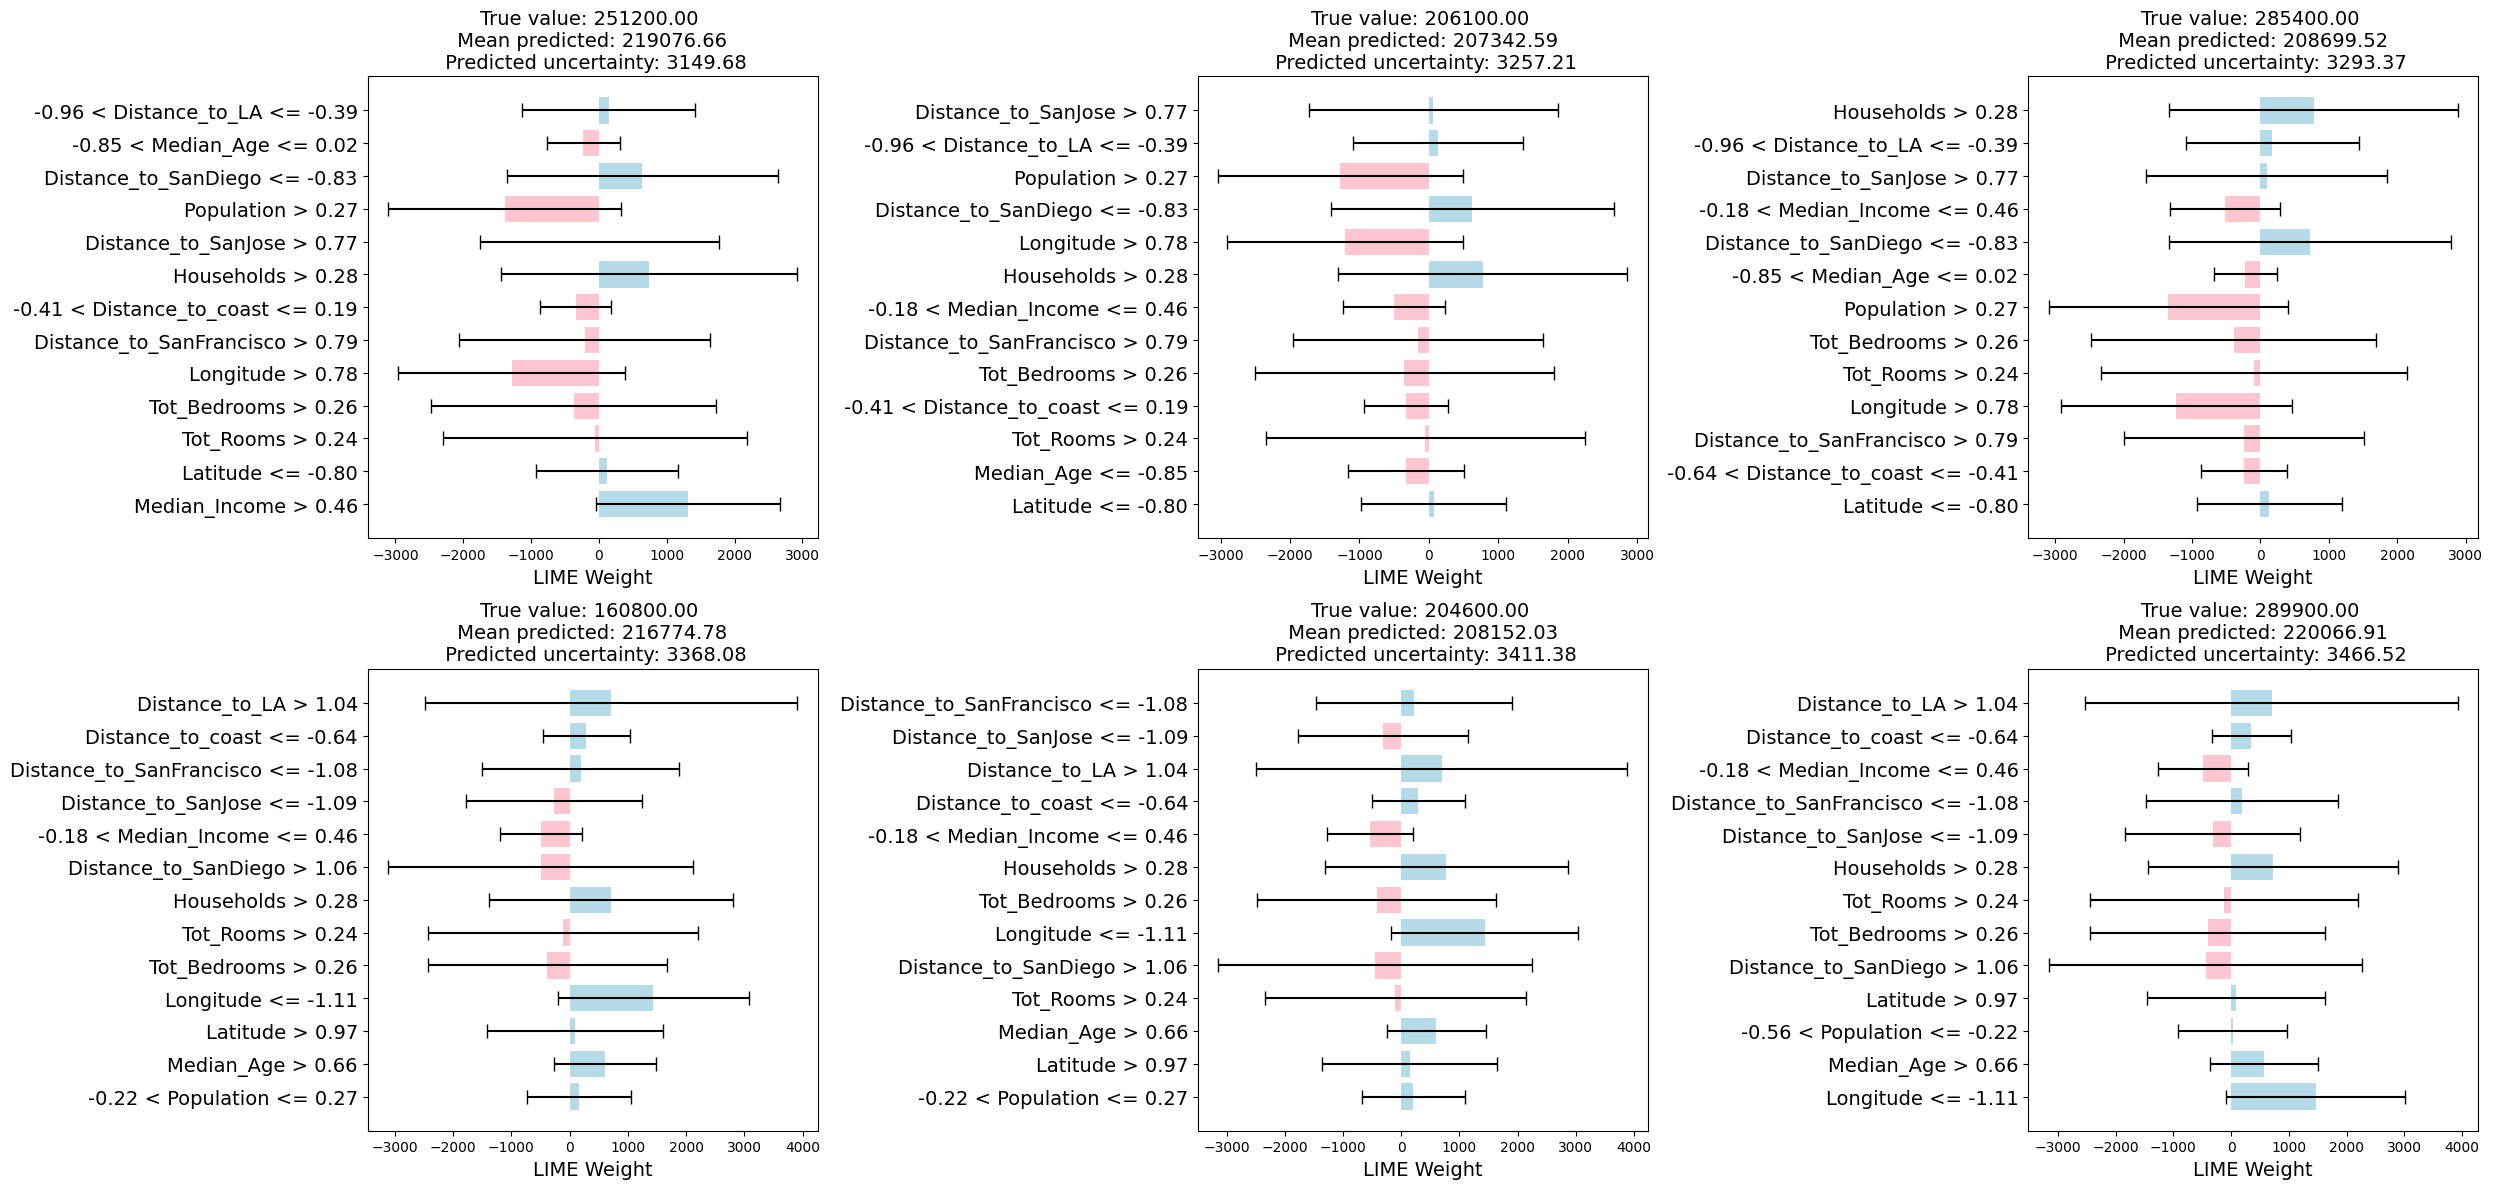

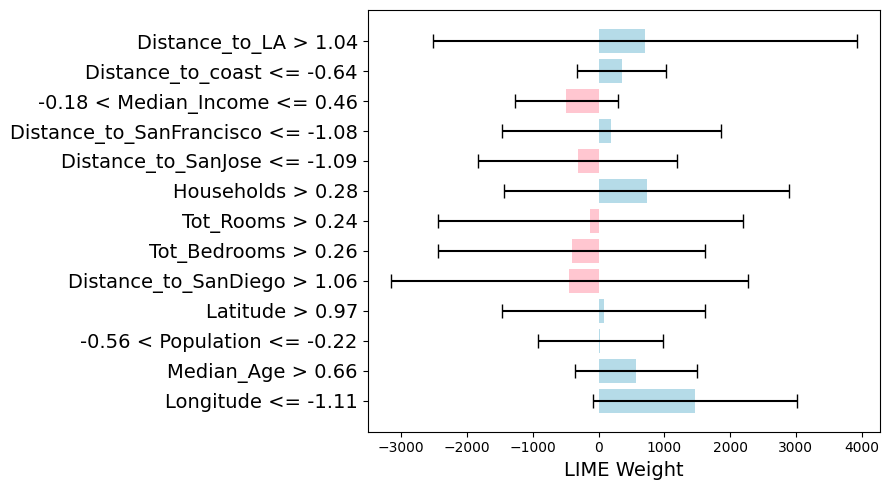

In [90]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have already defined these variables as in your original code snippet

# Extract data from the DataFrame
features_lime = gbt_cali_selected_explain_lime_df['Key'].tolist()
mean_weights_lime = gbt_cali_selected_explain_lime_df['Mean'].tolist()
std_weights_lime = gbt_cali_selected_explain_lime_df['Std'].tolist()

# Determine colors based on the sign of the mean weights
colors = ['lightblue' if weight > 0 else 'pink' for weight in mean_weights_lime]

# Number of features per plot
features_per_plot = 13

# Calculate the number of plots needed
num_plots = int(np.ceil(len(features_lime) / features_per_plot))

# Create subplots for all but the last plot
fig, axes = plt.subplots(2, 3, figsize=(25, 12))
axes = axes.flatten()  # Flatten the array to make it easier to iterate over

# Loop over the number of plots (except the last one)
for i in range(num_plots - 1):
    # Determine the range of features for this subplot
    start_idx = i * features_per_plot
    end_idx = min(start_idx + features_per_plot, len(features_lime))
    
    # Get the data for this range
    chunk_features = features_lime[start_idx:end_idx]
    chunk_mean_weights = mean_weights_lime[start_idx:end_idx]
    chunk_std_weights = std_weights_lime[start_idx:end_idx]
    chunk_colors = colors[start_idx:end_idx]
    
    # Create the horizontal bar plot for this chunk
    feature_ids = range(len(chunk_mean_weights))
    axes[i].barh(feature_ids, chunk_mean_weights, xerr=chunk_std_weights, capsize=5, alpha=0.9, color=chunk_colors)
    axes[i].set_yticks(feature_ids)
    axes[i].set_yticklabels(chunk_features, fontsize=14)
    axes[i].set_xlabel("LIME Weight", fontsize=14)
    title_true = sorted_gbt_cali_data.iloc[i,sorted_gbt_cali_data.columns.get_loc('y_test')]
    title_mean = sorted_gbt_cali_data.iloc[i,sorted_gbt_cali_data.columns.get_loc('mean_predict')]
    title_uncertainty = sorted_gbt_cali_data.iloc[i,sorted_gbt_cali_data.columns.get_loc('predicted_uncertainty')]
    axes[i].set_title(f"True value: {title_true:.2f} \n Mean predicted: {title_mean:.2f} \n Predicted uncertainty: {title_uncertainty:.2f}", fontsize=14)

# Adjust layout
plt.tight_layout()
plt.show()
# Plot the last plot separately
last_start_idx = (num_plots - 1) * features_per_plot
last_end_idx = len(features_lime)

fig_last, ax_last = plt.subplots(figsize=(9, 5))

# Get the data for the last range
chunk_features_last = features_lime[last_start_idx:last_end_idx]
chunk_mean_weights_last = mean_weights_lime[last_start_idx:last_end_idx]
chunk_std_weights_last = std_weights_lime[last_start_idx:last_end_idx]
chunk_colors_last = colors[last_start_idx:last_end_idx]

# Create the horizontal bar plot for the last chunk
feature_ids_last = range(len(chunk_mean_weights_last))
ax_last.barh(feature_ids_last, chunk_mean_weights_last, xerr=chunk_std_weights_last, capsize=5, alpha=0.9, color=chunk_colors_last)
ax_last.set_yticks(feature_ids_last)
ax_last.set_yticklabels(chunk_features_last, fontsize=14)
ax_last.set_xlabel("LIME Weight", fontsize=14)
# ax_last.set_title("Last Chunk of LIME Weights", fontsize=16)

# Adjust layout for the last plot
plt.tight_layout()

# Display all plots
plt.show()

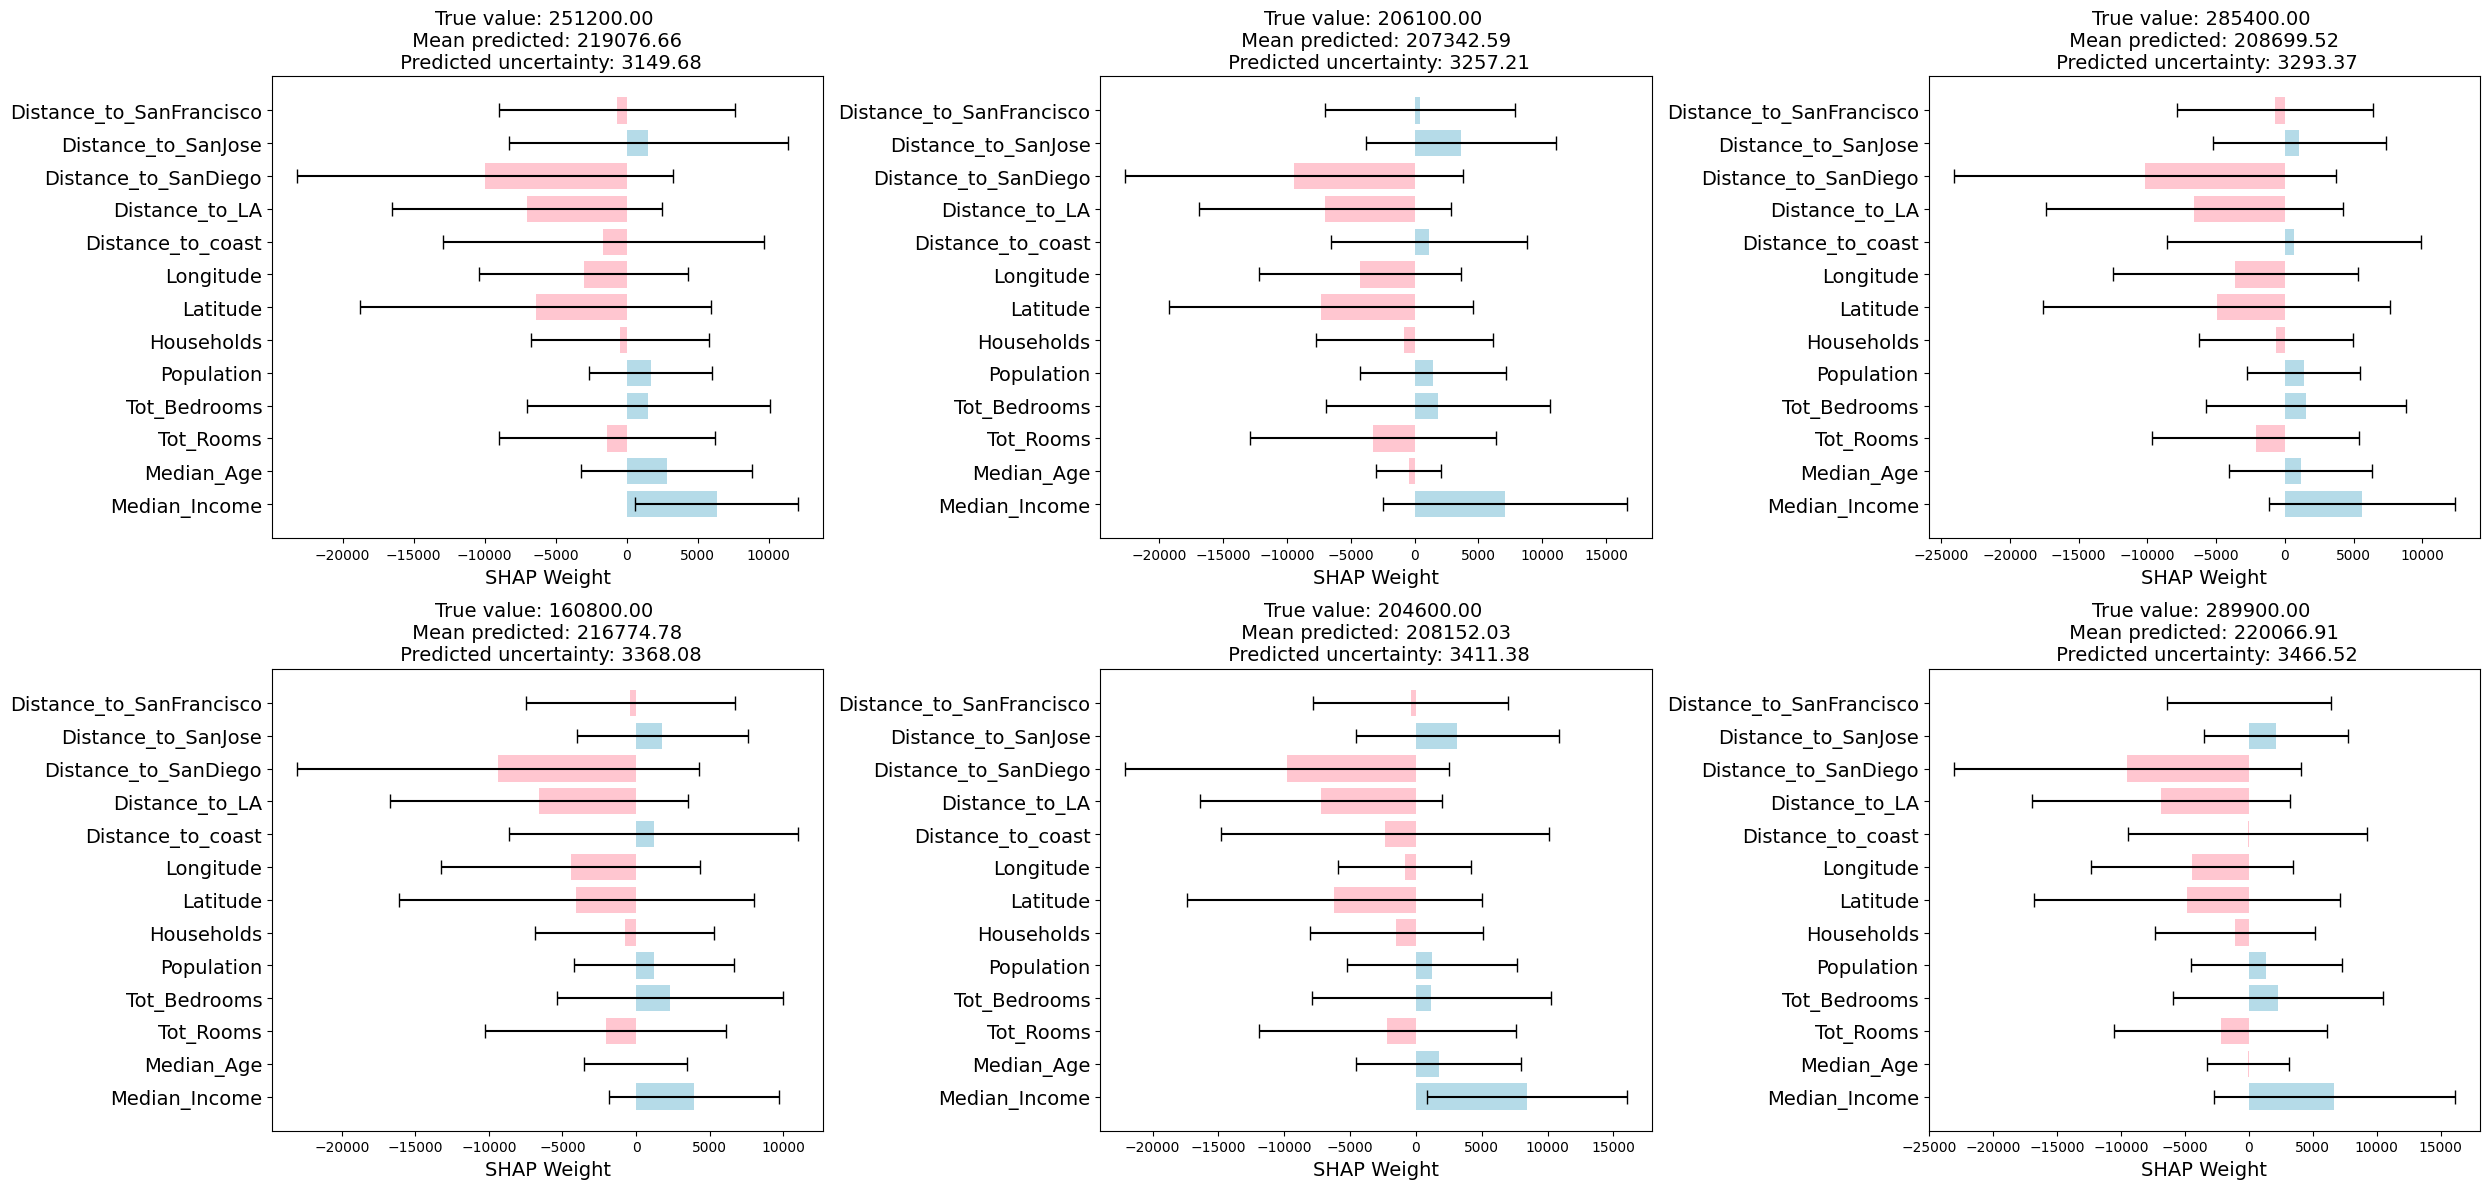

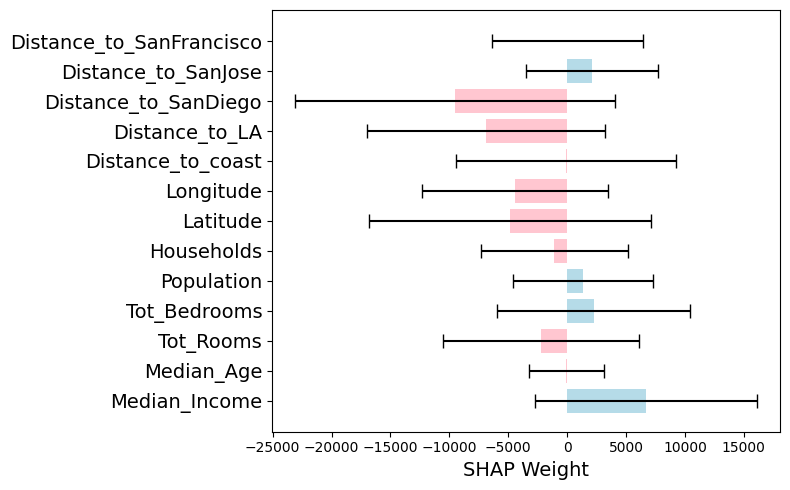

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have already defined these variables as in your original code snippet

# Extract data from the DataFrame
features_shap = flattened_shap_stats_df['Feature'].tolist()
mean_weights_shap = flattened_shap_stats_df['Mean'].tolist()
std_weights_shap = flattened_shap_stats_df['Std'].tolist()

# Determine colors based on the sign of the mean weights
colors = ['lightblue' if weight > 0 else 'pink' for weight in mean_weights_shap]

# Number of features per plot
features_per_plot = 13

# Calculate the number of plots needed
num_plots = int(np.ceil(len(features_shap) / features_per_plot))

# Create subplots for all but the last plot
fig, axes = plt.subplots(2, 3, figsize=(25, 12))  # Increase the figure size
axes = axes.flatten()  # Flatten the array to make it easier to iterate over

# Loop over the number of plots (except the last one)
for i in range(num_plots):
    # Determine the range of features for this subplot
    start_idx = i * features_per_plot
    end_idx = min(start_idx + features_per_plot, len(features_shap))
    
    # Get the data for this range
    chunk_features = features_shap[start_idx:end_idx]
    chunk_mean_weights = mean_weights_shap[start_idx:end_idx]
    chunk_std_weights = std_weights_shap[start_idx:end_idx]
    chunk_colors = colors[start_idx:end_idx]
    
    # Create the horizontal bar plot for this chunk
    feature_ids = range(len(chunk_mean_weights))
    axes[i].barh(feature_ids, chunk_mean_weights, xerr=chunk_std_weights, capsize=5, alpha=0.9, color=chunk_colors)
    axes[i].set_yticks(feature_ids)
    axes[i].set_yticklabels(chunk_features, fontsize=14)
    axes[i].set_xlabel("SHAP Weight", fontsize=14)
    title_true = sorted_gbt_cali_data.iloc[i,sorted_gbt_cali_data.columns.get_loc('y_test')]
    title_mean = sorted_gbt_cali_data.iloc[i,sorted_gbt_cali_data.columns.get_loc('mean_predict')]
    title_uncertainty = sorted_gbt_cali_data.iloc[i,sorted_gbt_cali_data.columns.get_loc('predicted_uncertainty')]
    axes[i].set_title(f"True value: {title_true:.2f} \n Mean predicted: {title_mean:.2f} \n Predicted uncertainty: {title_uncertainty:.2f}", fontsize=14)
    
# Adjust layout
plt.tight_layout()
plt.show()


# Plot the last plot separately
last_start_idx = (num_plots - 1) * features_per_plot
last_end_idx = len(features_shap)

fig_last, ax_last = plt.subplots(figsize=(8, 5))

# Get the data for the last range
chunk_features_last = features_shap[last_start_idx:last_end_idx]
chunk_mean_weights_last = mean_weights_shap[last_start_idx:last_end_idx]
chunk_std_weights_last = std_weights_shap[last_start_idx:last_end_idx]
chunk_colors_last = colors[last_start_idx:last_end_idx]

# Create the horizontal bar plot for the last chunk
feature_ids_last = range(len(chunk_mean_weights_last))
ax_last.barh(feature_ids_last, chunk_mean_weights_last, xerr=chunk_std_weights_last, capsize=5, alpha=0.9, color=chunk_colors_last)
ax_last.set_yticks(feature_ids_last)
ax_last.set_yticklabels(chunk_features_last, fontsize=14)
ax_last.set_xlabel("SHAP Weight", fontsize=14)

# Adjust layout for the last plot
plt.tight_layout()

# Display all plots
plt.show()